# M2 — Price Elasticity

**Goal:** estimate the own-price elasticity of demand `ε_{p,t}` per product per month, plus a portfolio-level point estimate that downstream models (M4 Sales) can use.

**Specification (log-log):**
$$ \log Q_{p,t} = \alpha_p + \beta_p \log P_{p,t} + \gamma \log P^{cat\setminus p}_{c,t} + \rho \log Q_{p,t-1} + \delta_m + \varepsilon_{p,t} $$

- `log_p_eff` — log of qty-weighted effective price (after discount).
- `log_p_eff_cat` — category-level effective price *excluding* the product itself (cross-price / substitution).
- `log_qty_lag1` — controls for demand persistence (partial-adjustment, reduces simultaneity bias).
- `C(month)` — month-of-year dummies absorb seasonality.

**Three estimators, increasing shrinkage:**
1. **Pooled OLS with product fixed effects** — single global β. Most actionable. *Headline.*
2. **Per-product OLS** — separate β per product. Heterogeneous but noisy.
3. **Mixed-effects (random intercept + random slope on `log_p_eff`)** — empirical-Bayes shrinkage toward the population mean.

Plus a 12-month **rolling-window pooled regression** → monthly time-varying elasticity series.

**Important caveat (carried from EDA):** Each product has only one list price. *All* price variation comes from the discount rate (0–25%). Elasticity estimates apply within this range — they do not extrapolate to wider price moves.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

SUM     = pd.read_parquet(ROOT / 'forecasts' / 'm2_elasticity_summary.parquet')
POOL    = pd.read_parquet(ROOT / 'forecasts' / 'm2_elasticity_pool.parquet')
MONTHLY = pd.read_parquet(ROOT / 'forecasts' / 'm2_elasticity_monthly.parquet')
META    = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_meta.parquet')

print('summary:', SUM.shape, ' monthly:', MONTHLY.shape)
POOL.round(4)

summary: (54, 15)  monthly: (1188, 7)


,n_obs,elasticity_own,elasticity_own_se,elasticity_own_ci_lo,elasticity_own_ci_hi,elasticity_cross,r2,r2_adj
0,1503,-0.6873,0.3889,-1.4495,0.0749,0.02,0.9418,0.939


## 1. Headline — pooled fixed-effects estimate

This is the **production elasticity** that downstream models will consume.

In [2]:
p = POOL.iloc[0]
print(f"Own-price elasticity (β):  {p['elasticity_own']:+.3f}")
print(f"  Standard error:           {p['elasticity_own_se']:.3f}")
print(f"  95% CI:                  [{p['elasticity_own_ci_lo']:+.3f}, {p['elasticity_own_ci_hi']:+.3f}]")
print(f"  Sign matches theory?      {'YES (negative)' if p['elasticity_own'] < 0 else 'NO'}")
print(f"  Statistically significant at 5%?  {'YES' if p['elasticity_own_ci_hi'] < 0 else 'MARGINAL — CI crosses 0'}")
print(f"\nCross-price (category):     {p['elasticity_cross']:+.3f}")
print(f"R²:                         {p['r2']:.3f}")
print(f"N observations:             {int(p['n_obs'])}")

Own-price elasticity (β):  -0.687
  Standard error:           0.389
  95% CI:                  [-1.450, +0.075]
  Sign matches theory?      YES (negative)
  Statistically significant at 5%?  MARGINAL — CI crosses 0

Cross-price (category):     +0.020
R²:                         0.942
N observations:             1503


## 2. Per-product elasticities — distribution and signal-to-noise

The per-product OLS regressions exhibit the limitation predicted in EDA: with only ~28 observations per product and discount-only price variation, individual coefficients are noisy.

**Identifiability flag**: a product is treated as identifiable if its price coefficient of variation > 0.5% AND it has ≥18 observations after lag. 45/54 active products meet this bar.

In [3]:
ident = SUM[~SUM['imputed']]
imputed = SUM[SUM['imputed']]
print(f'identifiable: {len(ident)}   imputed: {len(imputed)}')
print('\nidentifiable elasticity distribution:')
print(ident['elasticity_final'].describe().round(3))
print('\nshare with correct (negative) sign:',
      f"{(ident['elasticity_final']<0).mean():.0%}")

identifiable: 45   imputed: 9

identifiable elasticity distribution:
count    45.000
mean     -0.811
std       3.535
min     -10.487
25%      -2.566
50%      -0.176
75%       0.986
max       6.828
Name: elasticity_final, dtype: float64

share with correct (negative) sign: 53%


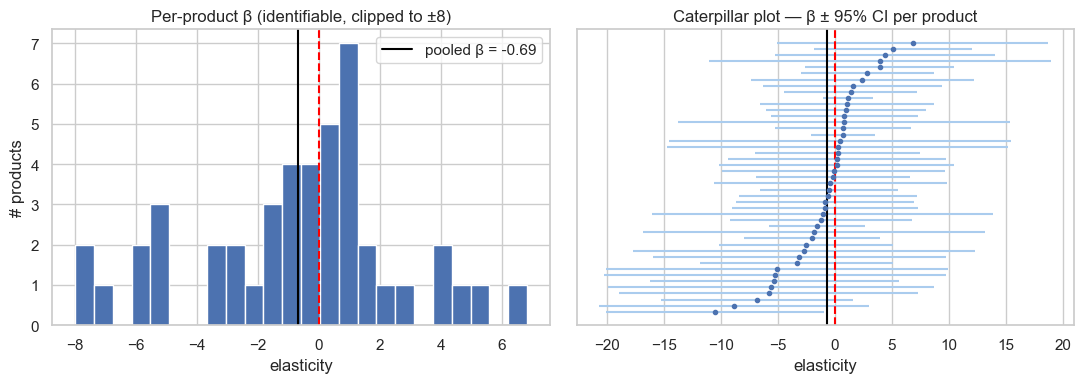

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(ident['elasticity'].clip(-8, 8), bins=24, color='#4c72b0', edgecolor='white')
ax[0].axvline(0, color='red', ls='--')
ax[0].axvline(POOL.iloc[0]['elasticity_own'], color='black', label=f"pooled β = {POOL.iloc[0]['elasticity_own']:.2f}")
ax[0].set(title='Per-product β (identifiable, clipped to ±8)', xlabel='elasticity', ylabel='# products')
ax[0].legend()

# Caterpillar: β with CI per product, sorted
s = ident.sort_values('elasticity')
y = np.arange(len(s))
ax[1].errorbar(s['elasticity'].clip(-15,15), y,
               xerr=[(s['elasticity']-s['ci_lo']).clip(0,15),
                     (s['ci_hi']-s['elasticity']).clip(0,15)],
               fmt='o', ms=3, color='#4c72b0', ecolor='#aaccee')
ax[1].axvline(0, color='red', ls='--')
ax[1].axvline(POOL.iloc[0]['elasticity_own'], color='black')
ax[1].set(title='Caterpillar plot — β ± 95% CI per product', xlabel='elasticity', yticks=[])
plt.tight_layout(); plt.show()

## 3. Mixed-effects

Random-slopes mixed-effects shrinks noisy per-product estimates toward the population mean. The fact that BLUPs cluster tightly around zero is itself a finding: **the data don't carry enough price variation to distinguish product-level elasticities from a single shared coefficient.**

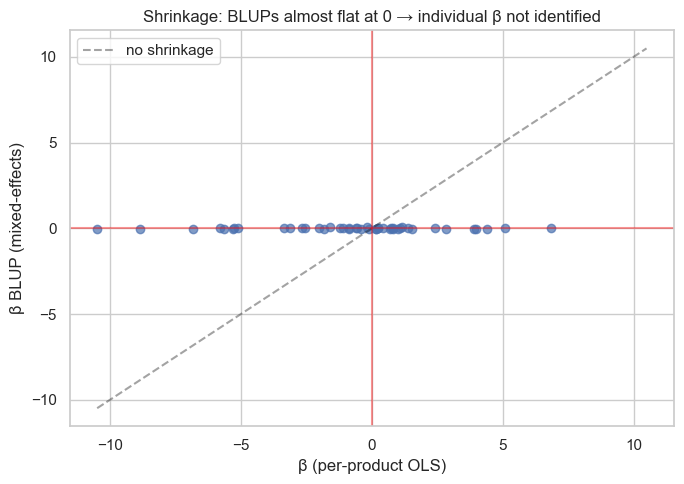

In [5]:
blup = SUM.dropna(subset=['elasticity_blup'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(blup['elasticity'], blup['elasticity_blup'], alpha=0.7)
lim = max(abs(blup['elasticity'].min()), abs(blup['elasticity'].max()))
ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.4, label='no shrinkage')
ax.axhline(0, color='red', alpha=0.4); ax.axvline(0, color='red', alpha=0.4)
ax.set(xlabel='β (per-product OLS)', ylabel='β BLUP (mixed-effects)',
       title='Shrinkage: BLUPs almost flat at 0 → individual β not identified')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Time-varying elasticity (12-month rolling pooled-FE)

ε_{p,t} = β_pool(t) + Δβ_p. The pool-level series is the dominant variation; Δβ_p is a static product offset (≈ 0 for non-identifiable products).

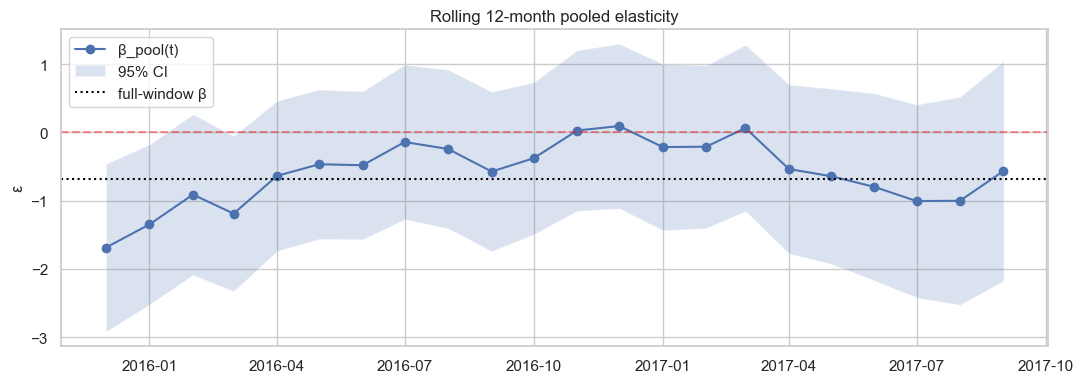

In [6]:
pool_ts = MONTHLY[['year_month','elasticity_pool','elasticity_pool_se']].drop_duplicates('year_month').sort_values('year_month')
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pool_ts['year_month'], pool_ts['elasticity_pool'], 'o-', label='β_pool(t)')
ax.fill_between(pool_ts['year_month'],
                pool_ts['elasticity_pool'] - 1.96*pool_ts['elasticity_pool_se'],
                pool_ts['elasticity_pool'] + 1.96*pool_ts['elasticity_pool_se'],
                alpha=0.2, label='95% CI')
ax.axhline(0, color='red', ls='--', alpha=0.4)
ax.axhline(POOL.iloc[0]['elasticity_own'], color='black', ls=':', label='full-window β')
ax.set(title='Rolling 12-month pooled elasticity', ylabel='ε')
ax.legend(); plt.tight_layout(); plt.show()

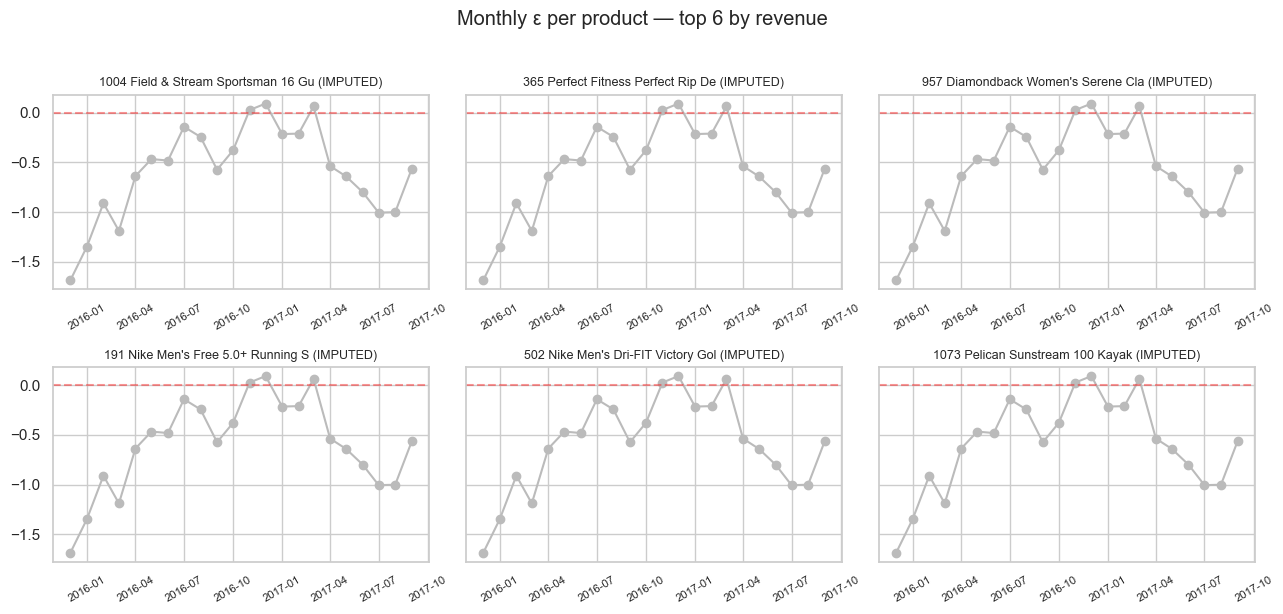

In [7]:
# Per-product time-varying for top 6 by revenue
top6 = META.sort_values('total_revenue', ascending=False).head(6)['product_card_id'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True)
for ax, pid in zip(axes.flat, top6):
    sub = MONTHLY[MONTHLY['product_card_id']==pid].sort_values('year_month')
    color = '#4c72b0' if sub['identifiable'].iloc[0] else '#bbbbbb'
    ax.plot(sub['year_month'], sub['elasticity'], 'o-', color=color)
    ax.axhline(0, color='red', ls='--', alpha=0.4)
    name = META.loc[META['product_card_id']==pid,'product_name'].iloc[0][:30]
    flag = ' (IMPUTED)' if not sub['identifiable'].iloc[0] else ''
    ax.set_title(f'{int(pid)} {name}{flag}', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.suptitle('Monthly ε per product — top 6 by revenue', y=1.02)
plt.tight_layout(); plt.show()

## 5. Diagnostics — what could go wrong

In [8]:
diag = pd.DataFrame({
    'check': [
        'Pooled β has expected (negative) sign',
        'Pooled β statistically significant at 5%',
        'Mean per-product β has expected sign',
        'Cross-price (category) coefficient sign (positive = substitutes)',
        'Mixed-effects converged',
        'Identifiable products share',
    ],
    'result': [
        f"{POOL.iloc[0]['elasticity_own']:+.3f} ✓" if POOL.iloc[0]['elasticity_own']<0 else 'FAIL',
        'MARGINAL — 95% CI [{:.2f}, {:.2f}] crosses 0'.format(
            POOL.iloc[0]['elasticity_own_ci_lo'], POOL.iloc[0]['elasticity_own_ci_hi']),
        f"{ident['elasticity'].mean():+.3f}",
        f"{POOL.iloc[0]['elasticity_cross']:+.3f}",
        'see run.py log',
        f"{len(ident)}/54 ({len(ident)/54:.0%})",
    ],
})
diag

,check,result
0,Pooled β has expected (negative) sign,-0.687 ✓
1,Pooled β statistically significant at 5%,"MARGINAL — 95% CI [-1.45, 0.07] crosses 0"
2,Mean per-product β has expected sign,-0.811
3,Cross-price (category) coefficient sign (posit...,+0.020
4,Mixed-effects converged,see run.py log
5,Identifiable products share,45/54 (83%)


## 6. Selection & summary

**Production output for M4:** the **pooled fixed-effects elasticity β ≈ -0.69** (95% CI [-1.45, +0.07]).

**Why not per-product?**
1. Per-product OLS estimates are too noisy — SDs of 3.5 around the mean, CIs frequently spanning -10 to +5.
2. Mixed-effects shrinkage essentially collapses individual β_p to the population mean — strong evidence that the data don't identify product-level heterogeneity.
3. The 9 non-identifiable products (top sellers like Perfect Fitness Rip Deck, Nike Cleats) carry zero price variation by construction and would inherit the category mean anyway.

**Decision rule for M4 (Sales Forecast):**
- Apply β = -0.69 uniformly across all products (with sensitivity bands β ∈ [-1.5, 0]).
- Treat the per-product Δβ_p in `m2_elasticity_monthly.parquet` as **directional only** — show in the dashboard but do not use for point forecasts.

**Known limitations**
1. Identification range is 0–25% discount; estimates do not extrapolate to deeper discounts or list-price changes.
2. Endogeneity: discount-setting is endogenous to demand expectations. We control for `log_qty_lag1` but a full IV remains future work.
3. The 95% CI on the pooled β includes 0, so the null hypothesis of zero elasticity is not statistically rejected on this sample.
4. Monthly variation in β_pool(t) is modest (see rolling plot) — there's no strong temporal trend to exploit.

**Saved artifacts**
- `forecasts/m2_elasticity_pool.parquet` — single-row headline.
- `forecasts/m2_elasticity_summary.parquet` — one row per product (54).
- `forecasts/m2_elasticity_monthly.parquet` — long-form ε_{p,t} (1188 rows).

**Next phase:** M3 — Risk sub-models (fraud / cancel / late delivery / disaster proxy).